# 03 - Atmospheric Temperature On Pressure Levels

Create a CMIP7 monthly air temperature file (`ta_tavg-p19-hxy-air`) on the requested 19 pressure levels.

In [1]:
from pathlib import Path
import json
import shutil

import cmor
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

start = Path.cwd().resolve()
for candidate in (start, *start.parents):
    if (candidate / "notebooks" / "NOTEBOOKS.md").exists() or (candidate / ".git").exists():
        REPO_ROOT = candidate
        break
else:
    REPO_ROOT = start

TABLES_REPO = REPO_ROOT / "cmip7-cmor-tables"
TABLES_DIR = TABLES_REPO / "tables"
if not TABLES_DIR.exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")

CV_FILE_FROM_TABLES_DIR = "../tables-cvs/cmor-cvs.json"

print(f"Using CMIP7 tables from {TABLES_REPO}")


Using CMIP7 tables from /Users/mauzey1/Desktop/github/cmor/cmip7-cmor-tables


In [2]:
run_dir = REPO_ROOT / "notebooks" / "output" / "03_pressure_level_air_temperature"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_FILE_FROM_TABLES_DIR,
    "activity_id": "CMIP",
    "calendar": "360_day",
    "drs_specs": "MIP-DRS7",
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "mip_era": "CMIP7",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
    "tracking_prefix": "hdl:21.14107",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

lat = np.arange(-85.0, 90.0, 10.0)
lat_bnds = np.arange(-90.0, 91.0, 10.0)
lon = np.arange(5.0, 360.0, 10.0)
lon_bnds = np.arange(0.0, 361.0, 10.0)
time = 15.0 + 30.0 * np.arange(2, dtype="f8")
time_bnds = 30.0 * np.arange(3, dtype="f8")
time_units = "days since 2018-01-01"
plev = np.array(
    [
        100000.0,
        92500.0,
        85000.0,
        70000.0,
        60000.0,
        50000.0,
        40000.0,
        30000.0,
        25000.0,
        20000.0,
        15000.0,
        10000.0,
        7000.0,
        5000.0,
        3000.0,
        2000.0,
        1000.0,
        500.0,
        100.0,
    ],
    dtype="f8",
)

seasonal_cycle = np.array([0.0, 1.2], dtype="f4")[:, None, None, None]
pressure_term = np.log(plev[None, :, None, None] / 100000.0)
lat_term = np.sin(np.deg2rad(lat))[None, None, :, None] ** 2
lon_term = np.cos(np.deg2rad(lon))[None, None, None, :]
ta = (285.0 + 32.0 * pressure_term - 35.0 * lat_term + lon_term + seasonal_cycle).astype("f4")

ta.shape


(2, 19, 18, 36)

In [3]:
cmor.setup(
    inpath=str(TABLES_DIR),
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))
cmor.load_table("CMIP7_atmos.json")

time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)
plev_id = cmor.axis("plev19", coord_vals=plev, units="Pa")
lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")
lon_id = cmor.axis("longitude", coord_vals=lon, cell_bounds=lon_bnds, units="degrees_east")

variable_name = "ta_tavg-p19-hxy-air"
ta_id = cmor.variable(variable_name, "K", [time_id, plev_id, lat_id, lon_id])
compound_name = ".".join(["atmos"] + variable_name.split("_") + ["mon", "glb"])

with open(TABLES_DIR / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(ta_id, "cell_measures", "c", cell_measure)

with open(TABLES_DIR / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(ta_id, "long_name", "c", long_name)

cmor.write(ta_id, ta)
netcdf_path = Path(cmor.close(ta_id, file_name=True))
cmor.close()

netcdf_path


PosixPath('/Users/mauzey1/Desktop/github/cmor/notebooks/output/03_pressure_level_air_temperature/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/ta/tavg-p19-hxy-air/g999/v20260529/ta_tavg-p19-hxy-air_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_201801-201802.nc')

In [4]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()
ds


<xarray.Dataset> Size: 100kB
Dimensions:    (time: 2, bnds: 2, lat: 18, lon: 36, plev: 19)
Coordinates:
  * time       (time) float64 16B 15.0 45.0
  * lat        (lat) float64 144B -85.0 -75.0 -65.0 -55.0 ... 65.0 75.0 85.0
  * lon        (lon) float64 288B 5.0 15.0 25.0 35.0 ... 325.0 335.0 345.0 355.0
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 32B 0.0 30.0 30.0 60.0
    lat_bnds   (lat, bnds) float64 288B -90.0 -80.0 -80.0 ... 80.0 80.0 90.0
    lon_bnds   (lon, bnds) float64 576B 0.0 10.0 10.0 20.0 ... 350.0 350.0 360.0
    ta         (time, plev, lat, lon) float32 98kB 251.3 251.2 ... 31.38 31.41
Attributes: (12/40)
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            air
    branded_variable:      ta_tavg-p19-hxy-air
    branding_suffix:       tavg-p19-hxy-air
    creation_date:         2026-05-29T20:52:09Z
    ...                    ...
    tracking_id:           hdl:21.14107/40ab0d49-419b-4b06-9fae-1f36c819c7bd
    variable_id:           ta
    variant_label:         r9i1p1f3
    vertical_label:        p19
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

In [5]:
print(ds[["ta"]])
print("pressure levels:", ds["plev"].values)
print("plev units:", ds["plev"].attrs.get("units"))


<xarray.Dataset> Size: 99kB
Dimensions:  (time: 2, plev: 19, lat: 18, lon: 36)
Coordinates:
  * time     (time) float64 16B 15.0 45.0
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat      (lat) float64 144B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * lon      (lon) float64 288B 5.0 15.0 25.0 35.0 ... 325.0 335.0 345.0 355.0
Data variables:
    ta       (time, plev, lat, lon) float32 98kB 251.3 251.2 ... 31.38 31.41
Attributes: (12/40)
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            air
    branded_variable:      ta_tavg-p19-hxy-air
    branding_suffix:       tavg-p19-hxy-air
    creation_date:         2026-05-29T20:52:09Z
    ...                    ...
    tracking_id:           hdl:21.14107/40ab0d49-419b-4b06-9fae-1f36c819c7bd
    variable_id:           ta
    variant_label:         r9i1p1f3
    vertical_label:        p19
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is lice

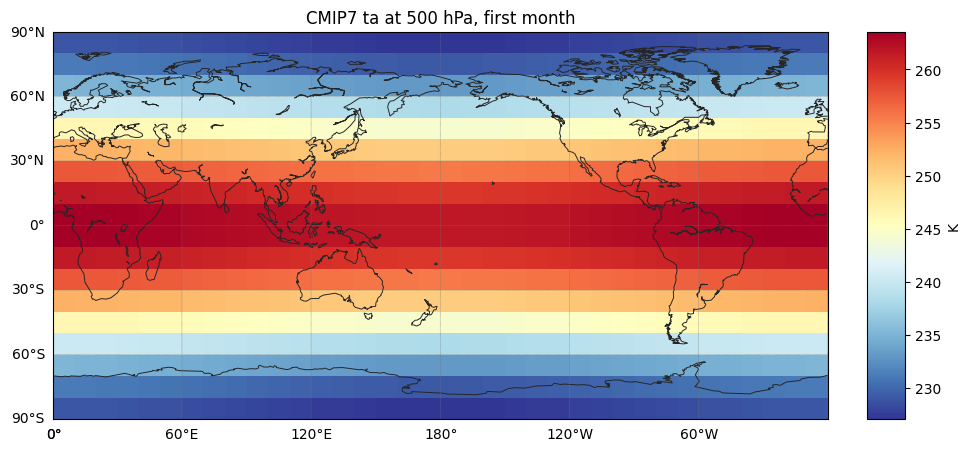

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.4))
map_plot = Basemap(
    projection="cyl",
    llcrnrlon=0,
    urcrnrlon=360,
    llcrnrlat=-90,
    urcrnrlat=90,
    resolution="c",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
lon_grid, lat_grid = np.meshgrid(ds["lon"].values, ds["lat"].values)
x, y = map_plot(lon_grid, lat_grid)
mesh = map_plot.pcolormesh(x, y, ds["ta"].sel(plev=50000.0).isel(time=0).values, shading="auto", cmap="RdYlBu_r")
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(-90, 91, 30), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(0, 361, 60), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("K")
ax.set_title("CMIP7 ta at 500 hPa, first month")
plt.show()
